# Data setup

In [3]:
# Importing packages
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, export_text, DecisionTreeRegressor
from IPython.display import Image
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score, confusion_matrix, r2_score
from sklearn.metrics import recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix, classification_report


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Reads the data and outputs the shape of the data and the column names, then shuffles the data.
file_path = "/content/drive/MyDrive/project 6912/Bankrupt data.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
print(df.shape)
print(df.columns)
df = df.sample(frac = 1, random_state = 0)

(6819, 96)
Index(['Bankrupt?', 'ROA(C) before interest and depreciation before interest',
       'ROA(A) before interest and % after tax',
       'ROA(B) before interest and depreciation after tax',
       'Operating Gross Margin', 'Realized Sales Gross Margin',
       'Operating Profit Rate', 'Pre-tax net Interest Rate',
       'After-tax net Interest Rate',
       'Non-industry income and expenditure/revenue',
       'Continuous interest rate (after tax)', 'Operating Expense Rate',
       'Research and development expense rate', 'Cash flow rate',
       'Interest-bearing debt interest rate', 'Tax rate (A)',
       'Net Value Per Share (B)', 'Net Value Per Share (A)',
       'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons',
       'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)',
       'Operating Profit Per Share (Yuan ¥)',
       'Per Share Net profit before tax (Yuan ¥)',
       'Realized Sales Gross Profit Growth Rate',
       'Operating Profit Growth Rate',

In [5]:
# Reads the first

df_train = df[:3000]
df_test = df[3000:5000]
df_vals = df[5000:]

# remove target column to create feature only dataset

# Splits the data into training, validation and testing
X_train, X_test, X_vals = df_train.drop('Bankrupt?',axis=1), df_test.drop('Bankrupt?',axis=1), df_vals.drop('Bankrupt?',axis=1)
# store target column
y_train, y_test, y_vals = df_train['Bankrupt?'], df_test['Bankrupt?'], df_vals['Bankrupt?']
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_vals.shape, y_vals.shape)

(3000, 95) (3000,)
(2000, 95) (2000,)
(1819, 95) (1819,)


# Logistic regression

In [6]:
# Initialize RandomOverSampler
oversampler = RandomOverSampler(sampling_strategy=0.25, random_state=0)

# Resample the training data
X_train2, y_train2 = oversampler.fit_resample(X_train, y_train)
X_test2, y_test2 = oversampler.fit_resample(X_test, y_test)
X_vals2, y_vals2 = oversampler.fit_resample(X_vals, y_vals)

In [7]:
# Initialize SMOTE with the desired sampling strategy
smote = SMOTE(sampling_strategy=0.5, random_state=0)

# Apply SMOTE to oversample the minority class
X_train_resampled, y_train_resampled = smote.fit_resample(X_train2, y_train2)
X_test_resampled, y_test_resampled = smote.fit_resample(X_test2, y_test2)
X_vals_resampled, y_vals_resampled = smote.fit_resample(X_vals2, y_vals2)

In [8]:
# Print the shape of resampled data
print(X_train_resampled.shape, y_train_resampled.shape)
print(X_test_resampled.shape, y_test_resampled.shape)
print(X_vals_resampled.shape, y_vals_resampled.shape)

(4366, 95) (4366,)
(2905, 95) (2905,)
(2626, 95) (2626,)


In [9]:
standardscalar = StandardScaler()
# Standardizing the data.
scaled_X_train = standardscalar.fit_transform(X_train_resampled)
scaled_X_test = standardscalar.transform(X_test_resampled)
scaled_X_vals = standardscalar.transform(X_vals_resampled)

In [10]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the logistic regression model without regularization
logreg = LogisticRegression(max_iter=1000)
logreg.fit(scaled_X_train, y_train_resampled)

LogisticRegression(max_iter=1000)

In [11]:
print(logreg.coef_)

[[-1.31394387  2.2872053   0.12811868 -0.4028174   1.1577595   0.10437647
   0.49239328 -0.75976277  0.48160021 -0.8448994  -0.00802781 -0.0702026
  -1.61960897 -0.10506631  0.24109417 -1.57358717 -0.10085698  1.01435537
  -1.66753829 -0.85378139 -0.06011025  0.73083855  1.24818886 -0.0658527
  -0.07955517 -0.26067731  0.34590514 -0.14996097 -0.0679526  -0.02849267
  -0.07049389  0.89229463 -2.10587787 -0.11465603 -0.0298496   1.73545242
   0.48098669 -0.48098669  0.02464497  2.79303499  0.56013695  0.13321358
  -1.74040273 -1.44827348 -0.4715273  -1.26536414 -0.12682651 -0.01243539
   0.23134796 -1.11453584  0.09064058 -0.21524765 -0.13611087 -0.34976285
   0.57641488  0.50723417 -0.56687684 -0.02849267  0.02462912  0.97761726
   1.56145871 -0.04785044 -0.69253682 -0.23383972  0.48743984 -0.21691055
  -0.87640776  0.07663823  0.14385625  0.02142472  0.21728615  0.18068841
   0.32564213 -0.53892023 -0.19662632  0.05204356 -0.23383972 -0.21691055
   0.24399384 -0.50020814 -0.41154788  0

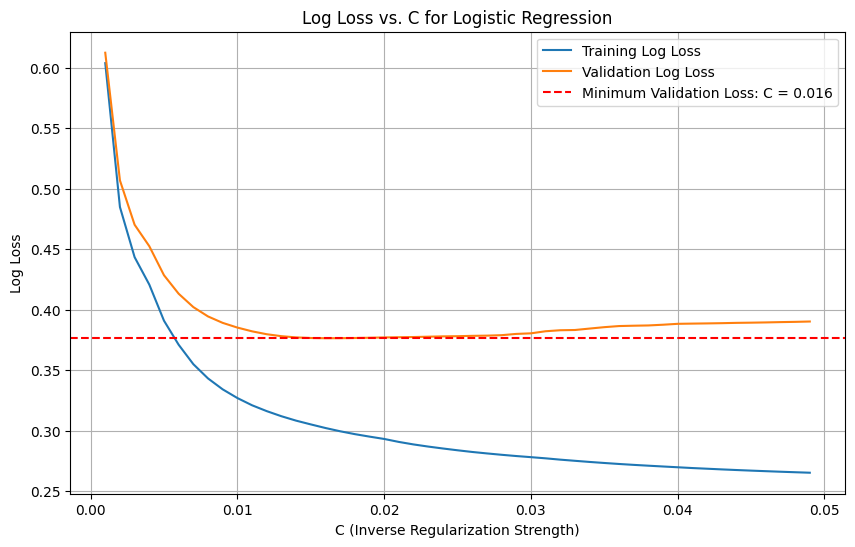

In [12]:
C_values = np.arange(0.001, 0.05, 0.001)
train_log_losses = []
val_log_losses = []

for C in C_values:
    # Initialize and train the logistic regression model with L1 regularization
    logreg = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', C=C, class_weight='balanced')
    logreg.fit(scaled_X_train, y_train_resampled)

    # Predict probabilities on training and validation sets
    train_probs = logreg.predict_proba(scaled_X_train)
    val_probs = logreg.predict_proba(scaled_X_vals)

    # Calculate log loss
    train_log_loss = log_loss(y_train_resampled, train_probs)
    val_log_loss = log_loss(y_vals_resampled, val_probs)

    train_log_losses.append(train_log_loss)
    val_log_losses.append(val_log_loss)


min_log_loss = min(val_log_losses)
min_index = val_log_losses.index(min_log_loss)


# Plot the log loss
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_log_losses, label='Training Log Loss')
plt.plot(C_values, val_log_losses, label='Validation Log Loss')
plt.axhline(y=min_log_loss, color='r', linestyle='--', label = f'Minimum Validation Loss: C = {C_values[min_index]}')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Log Loss')
plt.title('Log Loss vs. C for Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
logreg2 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', C = 0.017, class_weight = 'balanced')
logreg2.fit(scaled_X_train, y_train_resampled)

LogisticRegression(C=0.017, class_weight='balanced', max_iter=1000,
                   penalty='l1', solver='liblinear')

In [14]:
print(logreg2.coef_)

[[-0.61855835  0.          0.          0.          0.          0.
   0.          0.          0.         -0.02613515  0.          0.
   0.          0.          0.         -0.18714508  0.          0.
  -0.70845492 -0.04446027  0.          0.          0.          0.
   0.          0.          0.         -0.08750607  0.          0.
   0.          0.          0.          0.          0.          0.19458112
   0.82154419 -0.64455274  0.          0.          0.          0.
   0.          0.         -0.43476912  0.          0.          0.
   0.06881447  0.          0.         -0.00955366  0.         -0.14703173
   0.          0.         -0.07712857  0.          0.          0.10962544
   0.          0.         -0.01654562  0.          0.          0.
   0.         -0.00188384  0.          0.03319173  0.          0.
   0.         -0.25813272  0.          0.          0.          0.
   0.          0.         -0.22004748  0.          0.          0.
   0.         -0.23076339  0.          0.          0

In [15]:
# Get the coefficients of the logistic regression model
coefficients = logreg2.coef_

# Find the indices where the coefficients are non-zero
non_zero_indices = np.where(coefficients != 0)[1]

# Get the feature names corresponding to the non-zero coefficients
feature_names = X_train.columns[non_zero_indices]

# Print the names of the features with non-zero coefficients
feature_names


Index(['ROA(C) before interest and depreciation before interest',
       'Continuous interest rate (after tax)', 'Net Value Per Share (B)',
       'Persistent EPS in the Last Four Seasons', 'Cash Flow Per Share',
       'Continuous Net Profit Growth Rate', 'Total debt/Total net worth',
       'Debt ratio %', 'Net worth/Assets', 'Total Asset Turnover',
       'Fixed Assets Turnover Frequency', 'Operating profit per person',
       'Working Capital to Total Assets', 'Cash/Total Assets',
       'Current Liability to Assets', 'Inventory/Current Liability',
       'Retained Earnings to Total Assets', 'Total expense/Assets',
       'Cash Turnover Rate', 'Cash Flow to Liability',
       'Net Income to Total Assets', 'Degree of Financial Leverage (DFL)'],
      dtype='object')

In [16]:
# Predict on training set
y_train_pred = logreg.predict(scaled_X_train)

# Evaluate on training set
print("\nTraining Set (Resampled):")
print("Confusion Matrix:\n", confusion_matrix(y_train_resampled, y_train_pred))
print("Classification Report:\n", classification_report(y_train_resampled, y_train_pred, digits = 4))


# Prepare data for evaluation
X_val = df_vals.drop('Bankrupt?', axis=1)
y_val = df_vals['Bankrupt?']
X_test = df_test.drop('Bankrupt?', axis=1)
y_test = df_test['Bankrupt?']

# Predict on validation set
y_val_pred = logreg.predict(scaled_X_vals)

# Evaluate on validation set
print("Validation Set:")
print("Confusion Matrix:\n", confusion_matrix(y_vals_resampled, y_val_pred))
print("Classification Report:\n", classification_report(y_vals_resampled, y_val_pred, digits = 4))

# Predict on test set
y_test_pred = logreg.predict(scaled_X_test)

# Evaluate on test set
print("\nTest Set:")
print("Confusion Matrix:\n", confusion_matrix(y_test_resampled, y_test_pred))
print("Classification Report:\n", classification_report(y_test_resampled, y_test_pred, digits = 4))


Training Set (Resampled):
Confusion Matrix:
 [[2563  348]
 [  98 1357]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9632    0.8805    0.9200      2911
           1     0.7959    0.9326    0.8589      1455

    accuracy                         0.8978      4366
   macro avg     0.8795    0.9065    0.8894      4366
weighted avg     0.9074    0.8978    0.8996      4366

Validation Set:
Confusion Matrix:
 [[1507  244]
 [ 140  735]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9150    0.8607    0.8870      1751
           1     0.7508    0.8400    0.7929       875

    accuracy                         0.8538      2626
   macro avg     0.8329    0.8503    0.8399      2626
weighted avg     0.8603    0.8538    0.8556      2626


Test Set:
Confusion Matrix:
 [[1705  232]
 [ 190  778]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8997    

In [17]:
# Predict on training set
y_train_pred = logreg2.predict(scaled_X_train)

# Evaluate on training set
print("\nTraining Set (Resampled):")
print("Confusion Matrix:\n", confusion_matrix(y_train_resampled, y_train_pred))
print("Classification Report:\n", classification_report(y_train_resampled, y_train_pred, digits = 4))


# Prepare data for evaluation
X_val = df_vals.drop('Bankrupt?', axis=1)
y_val = df_vals['Bankrupt?']
X_test = df_test.drop('Bankrupt?', axis=1)
y_test = df_test['Bankrupt?']

# Predict on validation set
y_val_pred = logreg2.predict(scaled_X_vals)

# Evaluate on validation set
print("Validation Set:")
print("Confusion Matrix:\n", confusion_matrix(y_vals_resampled, y_val_pred))
print("Classification Report:\n", classification_report(y_vals_resampled, y_val_pred, digits = 4))

# Predict on test set
y_test_pred = logreg2.predict(scaled_X_test)

# Evaluate on test set
print("\nTest Set:")
print("Confusion Matrix:\n", confusion_matrix(y_test_resampled, y_test_pred))
print("Classification Report:\n", classification_report(y_test_resampled, y_test_pred, digits = 4))


Training Set (Resampled):
Confusion Matrix:
 [[2501  410]
 [  82 1373]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9683    0.8592    0.9104      2911
           1     0.7701    0.9436    0.8481      1455

    accuracy                         0.8873      4366
   macro avg     0.8692    0.9014    0.8793      4366
weighted avg     0.9022    0.8873    0.8897      4366

Validation Set:
Confusion Matrix:
 [[1473  278]
 [ 139  736]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9138    0.8412    0.8760      1751
           1     0.7258    0.8411    0.7792       875

    accuracy                         0.8412      2626
   macro avg     0.8198    0.8412    0.8276      2626
weighted avg     0.8512    0.8412    0.8438      2626


Test Set:
Confusion Matrix:
 [[1660  277]
 [  72  896]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9584    

[0.61631886 0.02748086 0.26588    ... 0.45496925 0.94632734 0.45496925]
AUC random predictions = 0.5
AUC predictions from logistic regression model = 0.9240673146255818
AUC predictions from penalized logistic regression model = 0.9400751780251475


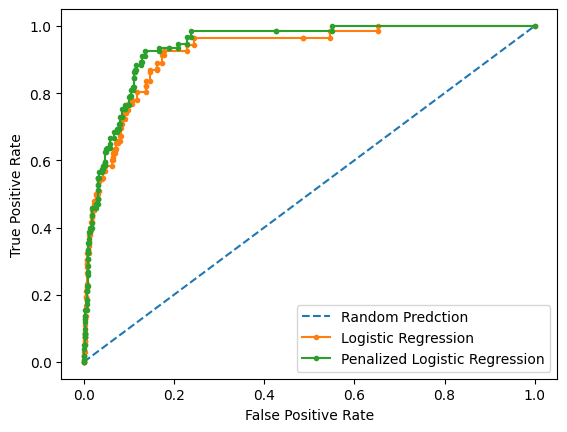

In [18]:

# Calculate the receiver operating curve and the AUC measure

lr_prob=logreg.predict_proba(scaled_X_test)
lr_prob2=logreg2.predict_proba(scaled_X_test)
lr_prob=lr_prob[:, 1]
lr_prob2 = lr_prob2[:, 1]
print(lr_prob)
ns_prob=[1 for _ in range(len(y_test_resampled))]
ns_auc=roc_auc_score(y_test_resampled, ns_prob)
lr_auc=roc_auc_score(y_test_resampled,lr_prob)
ns_prob2=[1 for _ in range(len(y_test_resampled))]
ns_auc2=roc_auc_score(y_test_resampled, ns_prob2)
lr_auc2=roc_auc_score(y_test_resampled,lr_prob2)
print("AUC random predictions =", ns_auc)
print("AUC predictions from logistic regression model =", lr_auc)
print("AUC predictions from penalized logistic regression model =", lr_auc2)
ns_fpr,ns_tpr,_=roc_curve(y_test_resampled,ns_prob)
lr_fpr,lr_tpr,_=roc_curve(y_test_resampled,lr_prob)
ns_fpr2,ns_tpr2,_=roc_curve(y_test_resampled,ns_prob2)
lr_fpr2,lr_tpr2,_=roc_curve(y_test_resampled,lr_prob2)

plt.plot(ns_fpr,ns_tpr,linestyle='--',label='Random Predction')
plt.plot(lr_fpr,lr_tpr,marker='.',label='Logistic Regression')
plt.plot(lr_fpr2,lr_tpr2,marker='.',label='Penalized Logistic Regression')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

#KNN

In [19]:
# Defining features and targets
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']
# Scaling dataset using Standard Scaler
X_scaled = StandardScaler().fit_transform(X)

In [20]:
# Using PCA to reduce the dimensionality and find the number of features with 90% and 95% variance
from sklearn.decomposition import PCA

pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)
print(pca_90.n_components_)

pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)
print(pca_95.n_components_)

45
53


In [21]:
# Calculating mutual information
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_scaled, y)
mi_scores = pd.Series(mi_selector.scores_, index=X.columns).dropna().sort_values(ascending=False)

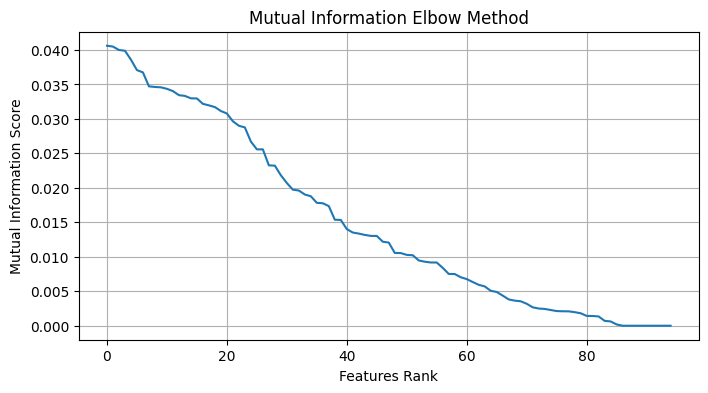

In [22]:
# Plotting mutual information with different numbers of feature to find elbow
plt.figure(figsize=(8, 4))
mi_scores.reset_index(drop=True).plot()
plt.title("Mutual Information Elbow Method")
plt.xlabel("Features Rank")
plt.ylabel("Mutual Information Score")
plt.grid(True)
plt.show()

In [23]:
# Showing the most important features and their mutual information score
for n in [5, 10, 13, 20, 45, 53]:
    print(f"\n Top {n} features that were identified by mutual information:")
    top_n = mi_scores.head(n)
    for feature, score in top_n.items():
        print(f"{feature}: {score:.4f}")


 Top 5 features that were identified by mutual information:
Persistent EPS in the Last Four Seasons: 0.0406
Net Income to Stockholder's Equity: 0.0405
Net profit before tax/Paid-in capital: 0.0400
Borrowing dependency: 0.0399
Per Share Net profit before tax (Yuan ¥): 0.0386

 Top 10 features that were identified by mutual information:
Persistent EPS in the Last Four Seasons: 0.0406
Net Income to Stockholder's Equity: 0.0405
Net profit before tax/Paid-in capital: 0.0400
Borrowing dependency: 0.0399
Per Share Net profit before tax (Yuan ¥): 0.0386
ROA(A) before interest and % after tax: 0.0371
Net Income to Total Assets: 0.0367
Continuous interest rate (after tax): 0.0347
Debt ratio %: 0.0346
Net worth/Assets: 0.0346

 Top 13 features that were identified by mutual information:
Persistent EPS in the Last Four Seasons: 0.0406
Net Income to Stockholder's Equity: 0.0405
Net profit before tax/Paid-in capital: 0.0400
Borrowing dependency: 0.0399
Per Share Net profit before tax (Yuan ¥): 0.03

In [24]:
# Creating a top features sets and store the storing results
results = []
top_n_list = [5, 10, 13, 20, 45, 53]

KNN Model with Top 5 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9805    0.9592    0.9697      1937
           1     0.2476    0.4127    0.3095        63

    accuracy                         0.9420      2000
   macro avg     0.6140    0.6860    0.6396      2000
weighted avg     0.9574    0.9420    0.9489      2000



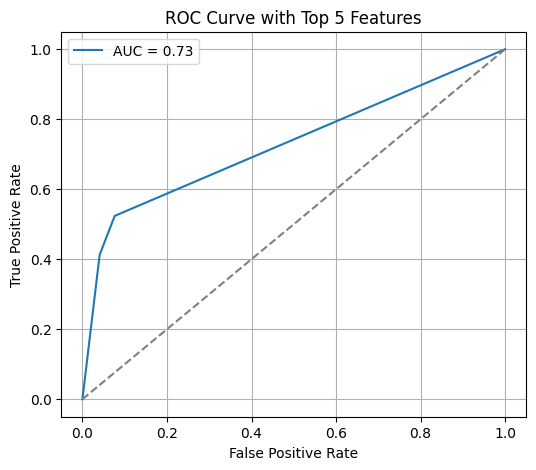

KNN Model with Top 10 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9805    0.9592    0.9697      1937
           1     0.2476    0.4127    0.3095        63

    accuracy                         0.9420      2000
   macro avg     0.6140    0.6860    0.6396      2000
weighted avg     0.9574    0.9420    0.9489      2000



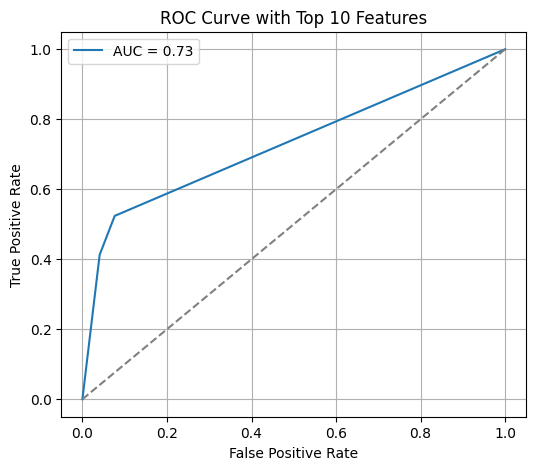

KNN Model with Top 13 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9805    0.9592    0.9697      1937
           1     0.2476    0.4127    0.3095        63

    accuracy                         0.9420      2000
   macro avg     0.6140    0.6860    0.6396      2000
weighted avg     0.9574    0.9420    0.9489      2000



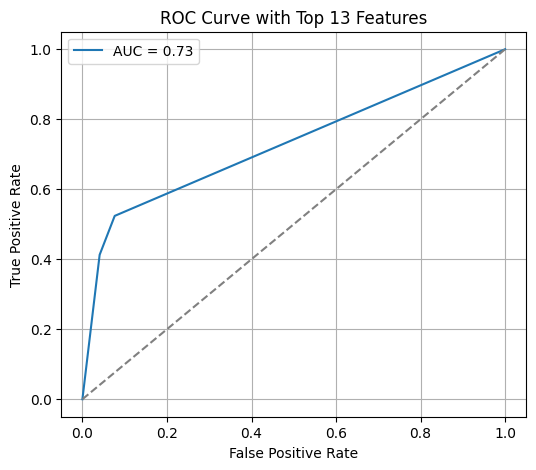

KNN Model with Top 20 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9805    0.9592    0.9697      1937
           1     0.2476    0.4127    0.3095        63

    accuracy                         0.9420      2000
   macro avg     0.6140    0.6860    0.6396      2000
weighted avg     0.9574    0.9420    0.9489      2000



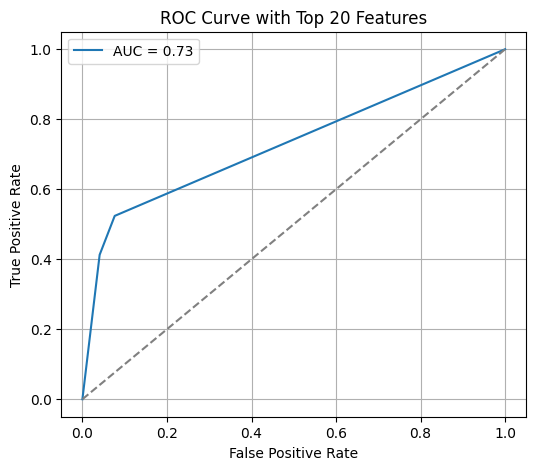

KNN Model with Top 45 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9805    0.9592    0.9697      1937
           1     0.2476    0.4127    0.3095        63

    accuracy                         0.9420      2000
   macro avg     0.6140    0.6860    0.6396      2000
weighted avg     0.9574    0.9420    0.9489      2000



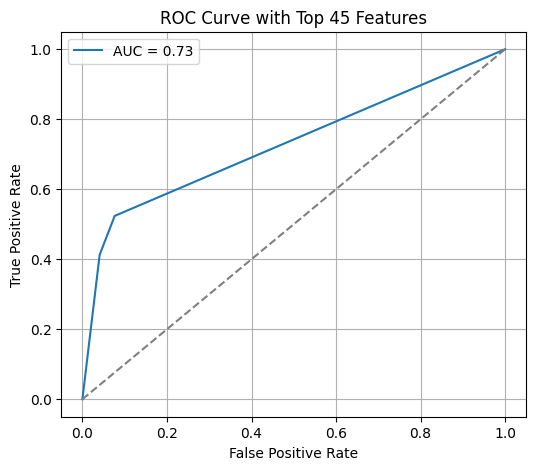

KNN Model with Top 53 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9805    0.9592    0.9697      1937
           1     0.2476    0.4127    0.3095        63

    accuracy                         0.9420      2000
   macro avg     0.6140    0.6860    0.6396      2000
weighted avg     0.9574    0.9420    0.9489      2000



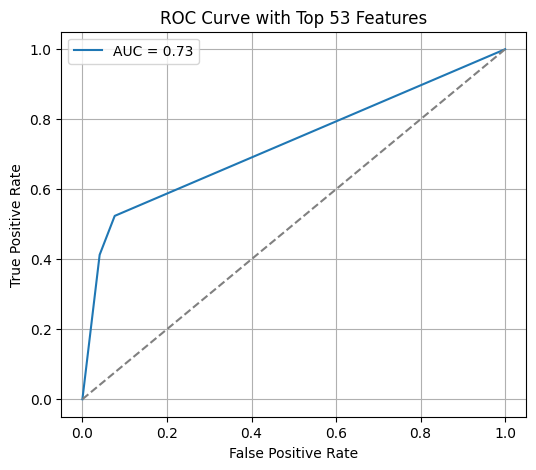

In [25]:
df_train = df[:3000]
df_test = df[3000:5000]
df_vals = df[5000:]

# remove target column to create feature only dataset

X_train, X_test, X_val = df_train.drop('Bankrupt?',axis=1), df_test.drop('Bankrupt?',axis=1), df_vals.drop('Bankrupt?',axis=1)
# store target column
y_train, y_test, y_val = df_train['Bankrupt?'], df_test['Bankrupt?'], df_vals['Bankrupt?']

# Setting up for loop to show each features
for n in top_n_list:
    print(f"KNN Model with Top {n} features:")

    # Selecting each top feature
    selected_features = mi_scores.head(n).index.tolist()

    # Obtaining features
    X_sel = X[selected_features]

    # Slicing dataset to 60% training set, 20% validation set, and 20% test set
   # X_temp, X_test, y_temp, y_test = train_test_split(X_sel, y, test_size=0.2, stratify=y, random_state=42)
   # X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

    # Scaling dataset for KNN model
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_val_std = scaler.transform(X_val)
    X_test_std = scaler.transform(X_test)

    # Fitting training set to smote to balance the data
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_std, y_train)

    # Checking the best K using cross validation
    best_k = 1
    best_f1 = 0
    for k_try in range(1, 21):
        knn_try = KNeighborsClassifier(n_neighbors=k_try)
        f1 = cross_val_score(knn_try, X_train_bal, y_train_bal, cv=5, scoring='f1').mean()
        if f1 > best_f1:
            best_k = k_try
            best_f1 = f1

    print(f"The best K is {best_k}")

    # Fitting balanced dataset to KNN classifier
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_bal, y_train_bal)

    # Using the test set and calculauting AUC
    y_pred = knn.predict(X_test_std)
    y_proba = knn.predict_proba(X_test_std)[:, 1]

    fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr_knn, tpr_knn)

    print(classification_report(y_test, y_pred, digits=4))

    # Plotting ROC AUC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr_knn, tpr_knn, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve with Top {n} Features")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Storing all results
    results.append({
        "Top K Features": n,
        "Best K": best_k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc
    })

# Decision tree

In [26]:
df_train = df[:3000]
df_test = df[3000:5000]
df_vals = df[5000:]

# remove target column to create feature only dataset

X_train, X_test, X_vals = df_train.drop('Bankrupt?',axis=1), df_test.drop('Bankrupt?',axis=1), df_vals.drop('Bankrupt?',axis=1)
# store target column
y_train, y_test, y_vals = df_train['Bankrupt?'], df_test['Bankrupt?'], df_vals['Bankrupt?']

(3000, 95) (3000,)
(2000, 95) (2000,)
(1819, 95) (1819,)


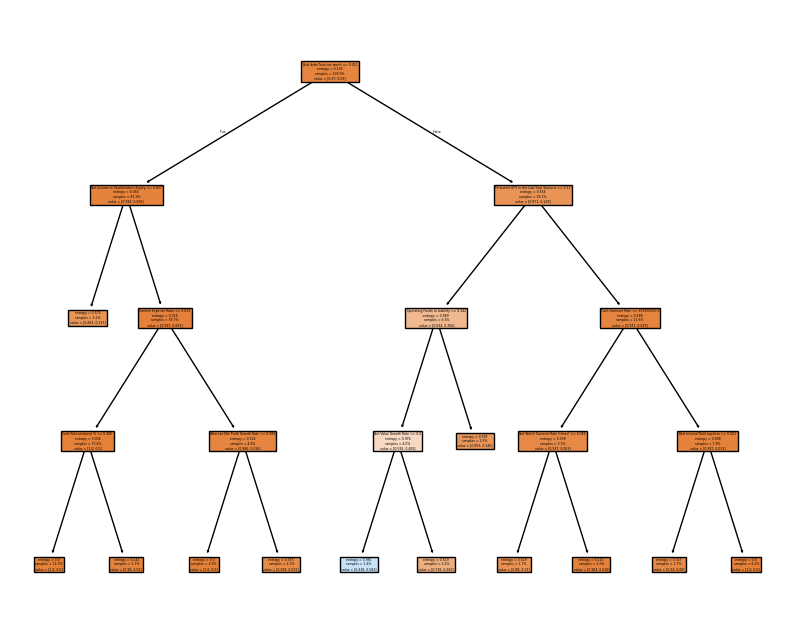

In [27]:
# Define a list of feature column
# We should delete some of the feature here:
selected_features = [
  'Net Value Growth Rate',
  'Net Income to Stockholder\'s Equity',
  'Persistent EPS in the Last Four Seasons',
  'Borrowing dependency',
  'Net profit before tax/Paid-in capital',
  'Non-industry income and expenditure/revenue',
  'Interest Expense Ratio',
  'Net Income to Total Assets',
  'Degree of Financial Leverage (DFL)',
  'Cash/Total Assets',
  'Net Value Per Share (B)',
  ''
]

# Select only these feature columns
#X_train = X_train[selected_features]
#X_test = X_test[selected_features]
#X_vals = X_vals[selected_features]
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verify the shape
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_vals.shape, y_vals.shape)

clf = DecisionTreeClassifier(criterion='entropy', max_depth=10, max_features = 'sqrt', min_samples_leaf=50, min_samples_split=2, random_state=40)
clf = clf.fit(X_train,y_train)
fig, ax = plt.subplots(figsize=(10, 8))
plot_tree(clf, filled=True, feature_names=X_train.columns, proportion=True)
plt.show()

(2000,)
[[1925   12]
 [  53   10]]


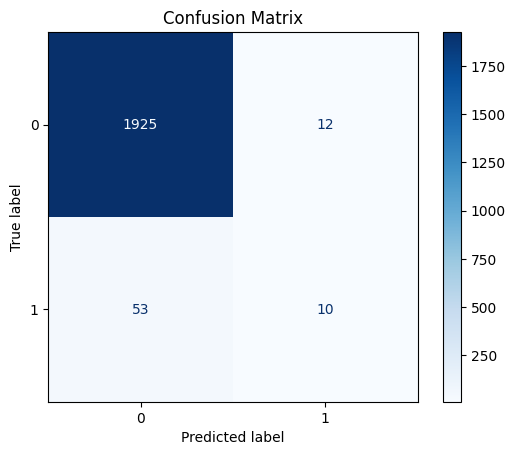

In [28]:

# Confusion Matrix
predictions2 = clf.predict(X_test)
cm3 = confusion_matrix(y_test, predictions2)
print(y_test.shape)
print(cm3)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [29]:
THRESHOLD = [.75, .80, .85]
results = pd.DataFrame(columns=["THRESHOLD", "accuracy", "true pos rate", "true neg rate", "false pos rate", "precision", "f-score"]) # df to store results
results['THRESHOLD'] = THRESHOLD                                                                           # threshold column
n_test = len(y_test)
Q = clf.predict_proba(X_test)[:,1]

j = 0
for i in THRESHOLD:                                                                                        # iterate over each threshold
                                                                         # fit data to model
    preds = np.where(Q>i, 1, 0)                                       # if prob > threshold, predict 1

    cm = (confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None)/n_test)*100
    # confusion matrix (in percentage)

    print('Confusion matrix for threshold =',i)
    print(cm)
    print(' ')

    TP = cm[0][0]                                                                                          # True Positives
    FN = cm[0][1]                                                                                          # False Positives
    FP = cm[1][0]                                                                                          # True Negatives
    TN = cm[1][1]                                                                                          # False Negatives

    results.iloc[j,1] = accuracy_score(y_test, preds)
    results.iloc[j,2] = recall_score(y_test, preds)
    results.iloc[j,3] = TN/(FP+TN)                                                                         # True negative rate
    results.iloc[j,4] = FP/(FP+TN)                                                                         # False positive rate
    results.iloc[j,5] = precision_score(y_test, preds)
    results.iloc[j,6] = f1_score(y_test, preds)

    j += 1

print('ALL METRICS')
print(results.T.to_string(header=False))

Confusion matrix for threshold = 0.75
[[ 0.    3.15]
 [ 0.   96.85]]
 
Confusion matrix for threshold = 0.8
[[ 0.    3.15]
 [ 0.   96.85]]
 
Confusion matrix for threshold = 0.85
[[ 0.    3.15]
 [ 0.   96.85]]
 
ALL METRICS
THRESHOLD         0.75     0.8    0.85
accuracy        0.9685  0.9685  0.9685
true pos rate      0.0     0.0     0.0
true neg rate      1.0     1.0     1.0
false pos rate     0.0     0.0     0.0
precision          0.0     0.0     0.0
f-score            0.0     0.0     0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# Compute the ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, Q)
roc_auc = auc(fpr,tpr)

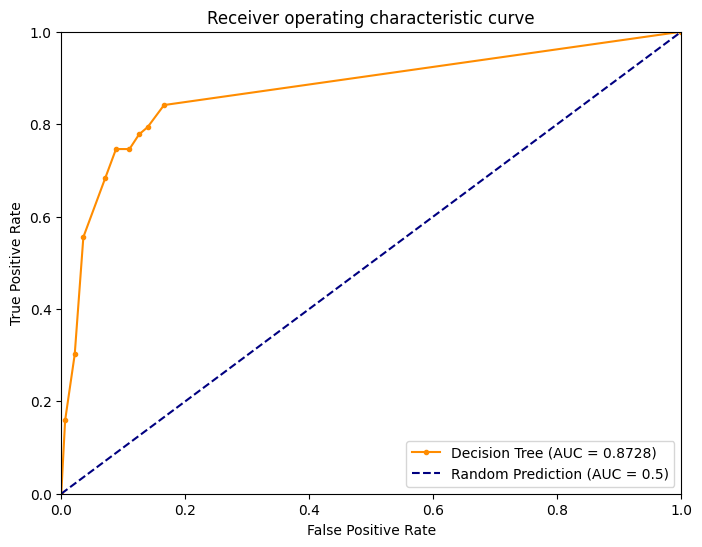

In [31]:
plt.figure(figsize=(8,6))      # format the plot size
lw = 1.5
plt.plot(fpr, tpr, color='darkorange', marker='.',
         lw=lw, label='Decision Tree (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--',
         label='Random Prediction (AUC = 0.5)' )
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic curve')
plt.legend(loc="lower right")
plt.show()

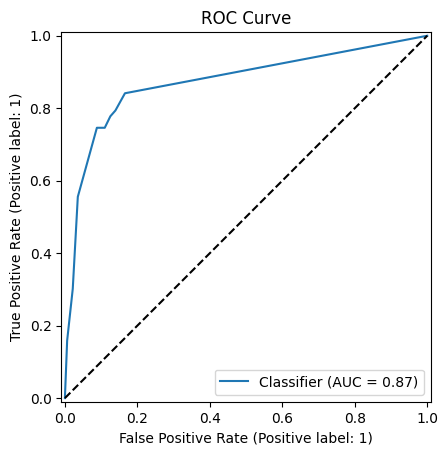

In [32]:
from sklearn.metrics import RocCurveDisplay

y_proba = clf.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.show()

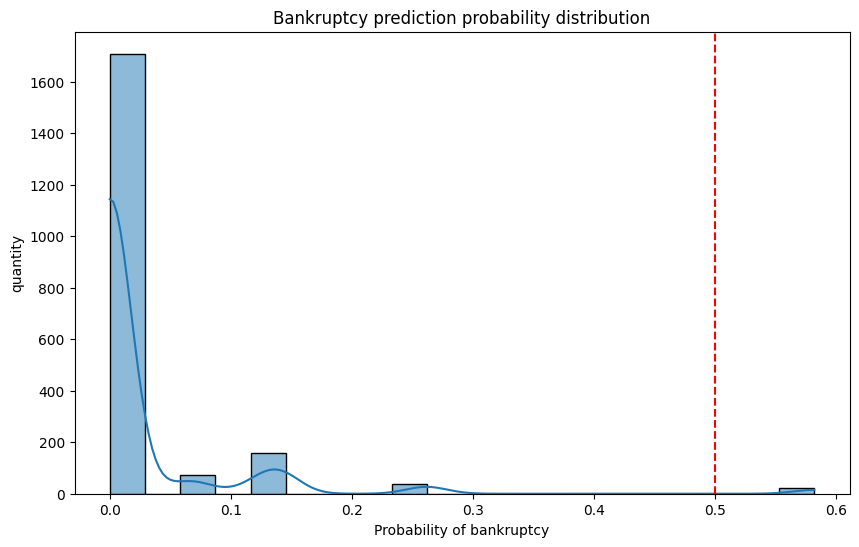

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(y_proba, bins=20, kde=True)
plt.title('Bankruptcy prediction probability distribution')
plt.xlabel('Probability of bankruptcy')
plt.ylabel('quantity')
plt.axvline(x=0.5, color='r', linestyle='--') # Decision threshold
plt.show()

# Random Forest

In [34]:
# Separating features and target variables
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

# Handling missing values ​​(if any)
X = X.fillna(X.mean())

# Standardize the data
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Split training set and test set
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [35]:
# Create the final model using the best parameters found
rf = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)

# Retrain on all training data (no need to keep validation set)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

Optimized model evaluation:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1937
           1       0.62      0.13      0.21        63

    accuracy                           0.97      2000
   macro avg       0.79      0.56      0.60      2000
weighted avg       0.96      0.97      0.96      2000


Confusion Matrix:
[[1932    5]
 [  55    8]]


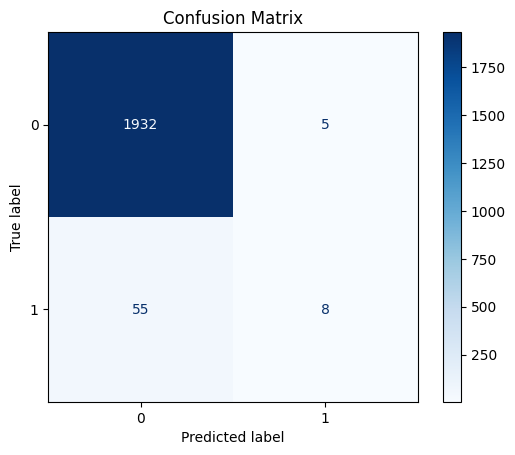

In [36]:
# Prediction test set
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # Get bankruptcy probability

print("Optimized model evaluation:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

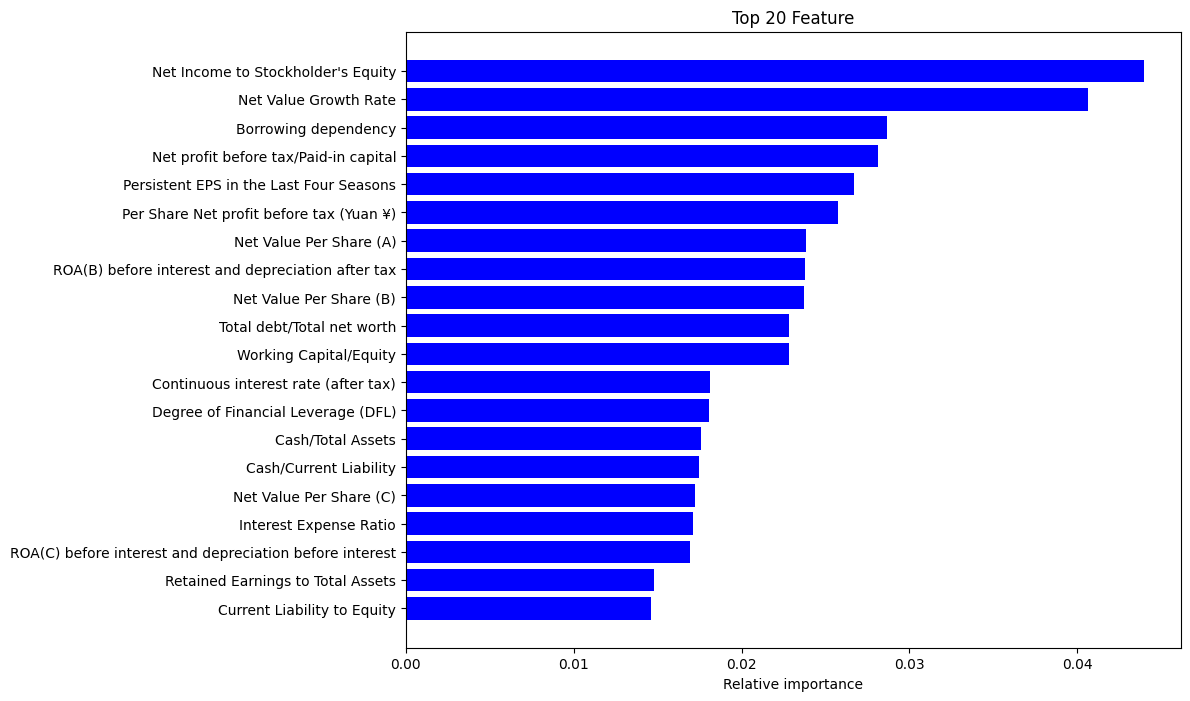

In [37]:
# Get feature importance
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[-20:]  # Take the 20 most important features

plt.figure(figsize=(10, 8))
plt.title('Top 20 Feature')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative importance')
plt.show()

## ROC and probability distribution

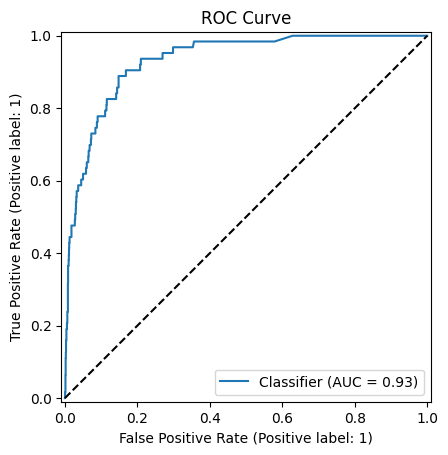

In [38]:
from sklearn.metrics import RocCurveDisplay

y_proba = rf.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.show()

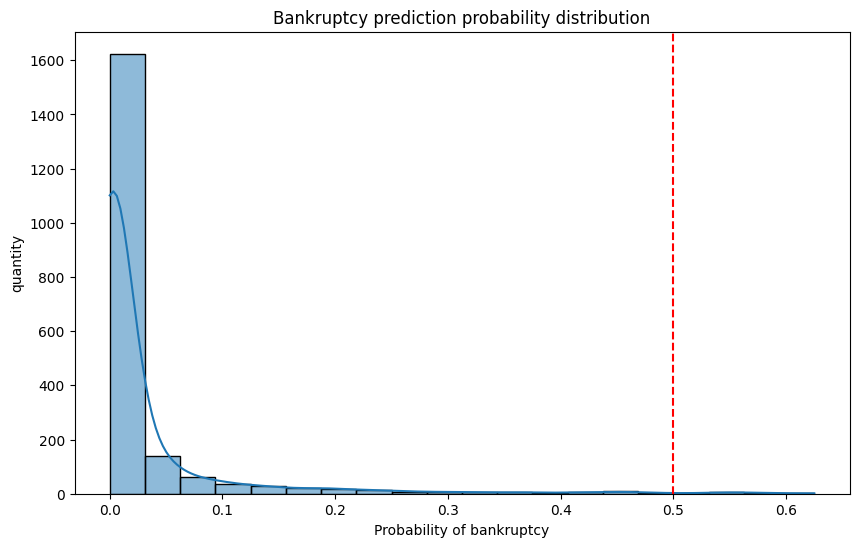

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(y_proba, bins=20, kde=True)
plt.title('Bankruptcy prediction probability distribution')
plt.xlabel('Probability of bankruptcy')
plt.ylabel('quantity')
plt.axvline(x=0.5, color='r', linestyle='--') # Decision threshold
plt.show()

# ROC curve total

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


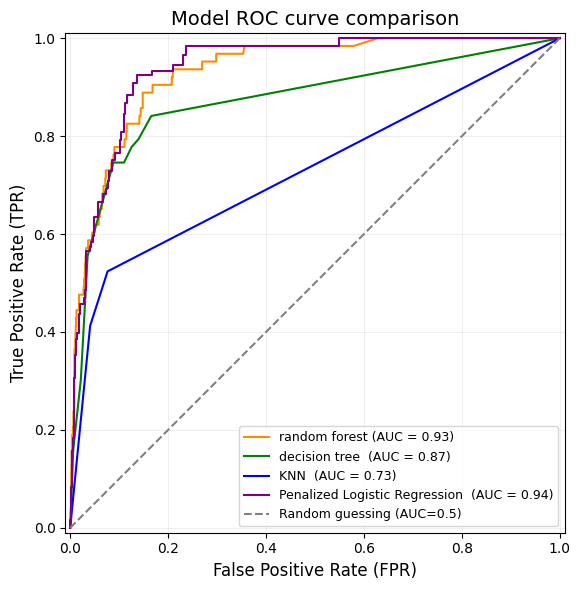

In [40]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# 1. Random Forest
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
RocCurveDisplay.from_predictions(
    y_test, rf_proba,
    name=f'random forest',
    color='darkorange',
    ax=plt.gca()
)

# 2. Decision Tree
dt_proba = clf.predict_proba(X_test)[:, 1]
dt_auc = roc_auc_score(y_test, dt_proba)
RocCurveDisplay.from_predictions(
    y_test, dt_proba,
    name=f'decision tree ',
    color='green',
    ax=plt.gca()
)

# 3. KNN
knn_proba = knn.predict_proba(X_test_std)[:, 1]
knn_auc = roc_auc_score(y_test, knn_proba)
RocCurveDisplay.from_predictions(
    y_test, knn_proba,
    name=f'KNN ',
    color='blue',
    ax=plt.gca()
)

# 4. Logistic regression (two variants)
lr_proba = logreg.predict_proba(X_test_resampled)[:, 1]
lr_auc = roc_auc_score(y_test_resampled, lr_proba)
lr_proba2 = logreg2.predict_proba(scaled_X_test)[:, 1]
lr_auc2 = roc_auc_score(y_test_resampled, lr_proba2)

RocCurveDisplay.from_predictions(
    y_test_resampled, lr_proba2,
    name=f'Penalized Logistic Regression ',
    color='purple',
    ax=plt.gca()
)

# Add random guides
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guessing (AUC=0.5)')
plt.title('Model ROC curve comparison', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()